# Support Integrity Auditor (SIA) — Full Pipeline
**Pseudo-labeling → Feature Engineering → Training → Inference → Dossiers**

In [26]:
import os

!git clone https://github.com/ToKYo4407/Mars-ai-ml-1.git
os.chdir("/content/Mars-ai-ml-1/ish")
print(os.getcwd())

Cloning into 'Mars-ai-ml-1'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (36/36), done.
Receiving objects: 100% (46/46), 39.62 KiB | 882.00 KiB/s, done.
remote: Total 46 (delta 14), reused 7 (delta 2), pack-reused 0 (from 0)
Resolving deltas: 100% (14/14), done.
/content/Mars-ai-ml-1/ish


## 0. Imports

In [27]:
import pandas as pd
import numpy as np
import joblib
import json
import os
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("models", exist_ok=True)
print("Ready.")

Ready.


## 1. Load Data

In [28]:
df = pd.read_csv("test_tickets.csv")
print(f"Rows: {len(df)}  |  Columns: {list(df.columns)}")
df.head()

Rows: 20  |  Columns: ['Ticket_Subject', 'Ticket_Description', 'Priority_Level', 'Issue_Category', 'Resolution_Time_Hours', 'Satisfaction_Score', 'Ticket_Channel']


,Ticket_Subject,Ticket_Description,Priority_Level,Issue_Category,Resolution_Time_Hours,Satisfaction_Score,Ticket_Channel
0,Production database outage,All customers unable to login and checkout,Low,Technical,1,1,Email
1,Payment processing failure,Credit card transactions failing across platform,Low,Billing,2,1,Chat
2,Website completely down,Homepage returning 500 errors for all users,Low,Technical,1,1,Web
3,Feature request dark mode,Customer would like dark mode support,Critical,Feature_Request,72,5,Email
4,Minor spelling mistake,Typo found in settings page,Critical,General,96,5,Chat


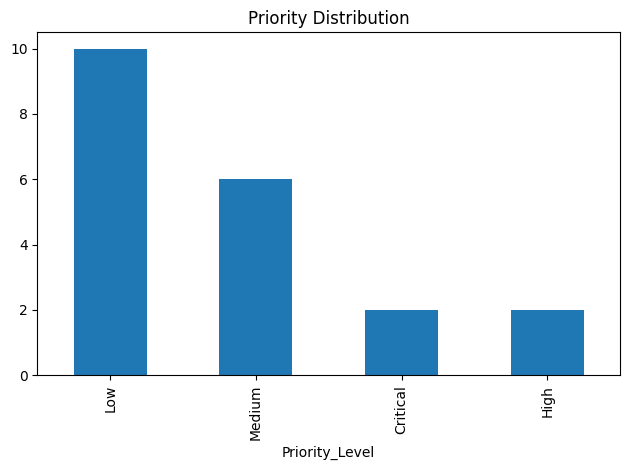

In [29]:
df['Priority_Level'].value_counts().plot(kind='bar', title='Priority Distribution')
plt.tight_layout()
plt.show()

## 2. Signal Functions
Two heuristic signals that estimate real severity from raw ticket content.

In [30]:
def text_severity(subject, description):
    text = (str(subject) + " " + str(description)).lower()
    critical = ["crash", "down", "dead", "emergency", "cannot access", "outage"]
    high     = ["error", "failed", "unable", "broken"]
    score = 0.30
    if any(w in text for w in critical):
        score = 0.90
    elif any(w in text for w in high):
        score = 0.65
    if text.count("!") >= 2:
        score = min(score + 0.10, 0.95)
    if "urgent" in text:
        score = min(score + 0.08, 0.95)
    return float(np.clip(score, 0, 1))


def metadata_severity(hours, satisfaction, category):
    res_sev = (
        0.90 if hours <= 1  else
        0.80 if hours <= 2  else
        0.65 if hours <= 6  else
        0.50 if hours <= 24 else 0.30
    )
    sat_sev = (
        0.85 if satisfaction <= 1 else
        0.65 if satisfaction <= 2 else
        0.45 if satisfaction <= 3 else 0.20
    )
    cat_risk = {
        "Technical": 0.75, "Billing": 0.70,
        "General": 0.35,   "Feature_Request": 0.25,
    }.get(category, 0.50)
    return float(np.clip(res_sev * 0.40 + sat_sev * 0.35 + cat_risk * 0.25, 0, 1))


print("Signal functions defined.")

Signal functions defined.


## 3. Pseudo-Labeling
Since we have no ground-truth mismatch labels, we derive them:
1. Compute inferred severity from signals
2. Compare to the assigned priority
3. Tickets in the top 25% severity delta → labelled **mismatch (1)**

Delta threshold (75th pct): 0.661
Mismatch (1): 5  |  Consistent (0): 15


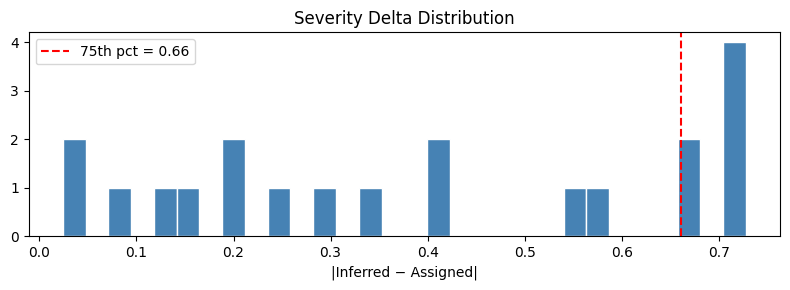

In [31]:
PRIORITY_MAP = {"Critical": 0.95, "High": 0.70, "Medium": 0.45, "Low": 0.15}

signal_1 = np.array([
    text_severity(df.iloc[i]["Ticket_Subject"], df.iloc[i]["Ticket_Description"])
    for i in range(len(df))
])
signal_2 = np.array([
    metadata_severity(
        df.iloc[i]["Resolution_Time_Hours"],
        df.iloc[i]["Satisfaction_Score"],
        df.iloc[i]["Issue_Category"],
    )
    for i in range(len(df))
])

inferred   = signal_1 * 0.60 + signal_2 * 0.40
assigned   = df["Priority_Level"].map(PRIORITY_MAP).values
delta      = np.abs(inferred - assigned)
threshold  = np.percentile(delta, 75)
y          = (delta > threshold).astype(int)

print(f"Delta threshold (75th pct): {threshold:.3f}")
print(f"Mismatch (1): {y.sum()}  |  Consistent (0): {(y==0).sum()}")

plt.figure(figsize=(8, 3))
plt.hist(delta, bins=30, color='steelblue', edgecolor='white')
plt.axvline(threshold, color='red', linestyle='--', label=f'75th pct = {threshold:.2f}')
plt.title('Severity Delta Distribution')
plt.xlabel('|Inferred − Assigned|')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [32]:
# TF-IDF on subject + description
vectorizer   = TfidfVectorizer(max_features=250, ngram_range=(1, 2), min_df=1, max_df=0.95)
text_combined = df["Ticket_Subject"].astype(str) + " " + df["Ticket_Description"].astype(str)
text_features = vectorizer.fit_transform(text_combined).toarray()

# Scale numeric metadata
scaler          = StandardScaler()
metadata        = df[["Resolution_Time_Hours", "Satisfaction_Score"]].values
metadata_scaled = scaler.fit_transform(metadata)

# Concatenate all features
signal_features = np.column_stack([signal_1, signal_2])
X = np.hstack([text_features, metadata_scaled, signal_features])

print(f"Feature matrix: {X.shape}  (samples × features)")

Feature matrix: (20, 254)  (samples × features)


## 5. Training

In [33]:
model = GradientBoostingClassifier(n_estimators=100, random_state=42)
model.fit(X, y)
print("Training complete.")

Training complete.


In [34]:
# Cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='f1')
print(f"5-fold F1: {cv_scores.round(3)}")
print(f"Mean F1:   {cv_scores.mean():.3f}  ±  {cv_scores.std():.3f}")

5-fold F1: [1.    1.    0.    0.667 1.   ]
Mean F1:   0.733  ±  0.389


              precision    recall  f1-score   support

  Consistent       1.00      1.00      1.00        15
    Mismatch       1.00      1.00      1.00         5

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



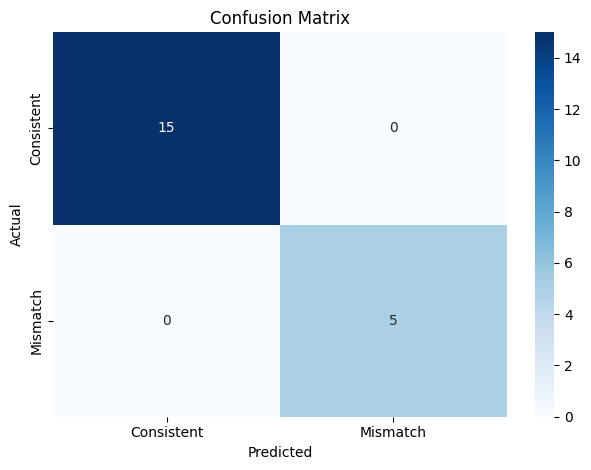

In [35]:
# Full-dataset evaluation
y_pred  = model.predict(X)
y_proba = model.predict_proba(X)[:, 1]

print(classification_report(y, y_pred, target_names=["Consistent", "Mismatch"]))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Consistent", "Mismatch"],
            yticklabels=["Consistent", "Mismatch"])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 6. Save Model

In [36]:
joblib.dump(model,      "models/sia_model.pkl")
joblib.dump(vectorizer, "models/vectorizer.pkl")
joblib.dump(scaler,     "models/scaler.pkl")
print("Saved: models/sia_model.pkl, vectorizer.pkl, scaler.pkl")

Saved: models/sia_model.pkl, vectorizer.pkl, scaler.pkl


## 7. Inference — Load & Predict

In [37]:
MODELS_DIR = os.path.join(os.getcwd(), "models")

model_loaded      = joblib.load(os.path.join(MODELS_DIR, "sia_model.pkl"))
vectorizer_loaded = joblib.load(os.path.join(MODELS_DIR, "vectorizer.pkl"))
scaler_loaded     = joblib.load(os.path.join(MODELS_DIR, "scaler.pkl"))

df_infer = pd.read_csv(os.path.join(os.getcwd(), "test_tickets.csv"))

text_f = vectorizer_loaded.transform(
    df_infer["Ticket_Subject"].astype(str) + " " + df_infer["Ticket_Description"].astype(str)
).toarray()
meta_f = scaler_loaded.transform(df_infer[["Resolution_Time_Hours", "Satisfaction_Score"]].values)

s1 = np.array([text_severity(df_infer.iloc[i]["Ticket_Subject"], df_infer.iloc[i]["Ticket_Description"]) for i in range(len(df_infer))])
s2 = np.array([metadata_severity(df_infer.iloc[i]["Resolution_Time_Hours"], df_infer.iloc[i]["Satisfaction_Score"], df_infer.iloc[i]["Issue_Category"]) for i in range(len(df_infer))])

X_infer  = np.hstack([text_f, meta_f, np.column_stack([s1, s2])])
proba    = model_loaded.predict_proba(X_infer)[:, 1]
preds    = (proba >= 0.50).astype(int)
inferred = s1 * 0.60 + s2 * 0.40
assigned = df_infer["Priority_Level"].map(PRIORITY_MAP).values

labels = []
for i in range(len(df_infer)):
    if preds[i] == 0:
        labels.append("Consistent")
    elif inferred[i] > assigned[i]:
        labels.append("Hidden Crisis")
    else:
        labels.append("False Alarm")

results = df_infer[["Ticket_Subject", "Priority_Level"]].copy()
results["Prediction"]        = labels
results["Confidence"]        = proba.round(3)
results["Inferred_Severity"] = inferred.round(3)
results["Severity_Delta"]    = np.abs(inferred - assigned).round(3)

results.head(10)

,Ticket_Subject,Priority_Level,Prediction,Confidence,Inferred_Severity,Severity_Delta
0,Production database outage,Low,Hidden Crisis,1.0,0.878,0.728
1,Payment processing failure,Low,Consistent,0.0,0.497,0.347
2,Website completely down,Low,Hidden Crisis,1.0,0.878,0.728
3,Feature request dark mode,Critical,False Alarm,1.0,0.281,0.669
4,Minor spelling mistake,Critical,Consistent,0.0,0.291,0.659
5,Add export button,High,Consistent,0.0,0.281,0.419
6,Unable to reset password,Medium,Consistent,0.0,0.660,0.210
7,Invoice mismatch,Medium,Consistent,0.0,0.421,0.029
8,Intermittent API errors,Medium,Consistent,0.0,0.660,0.210
9,Login page crash,Low,Hidden Crisis,1.0,0.878,0.728


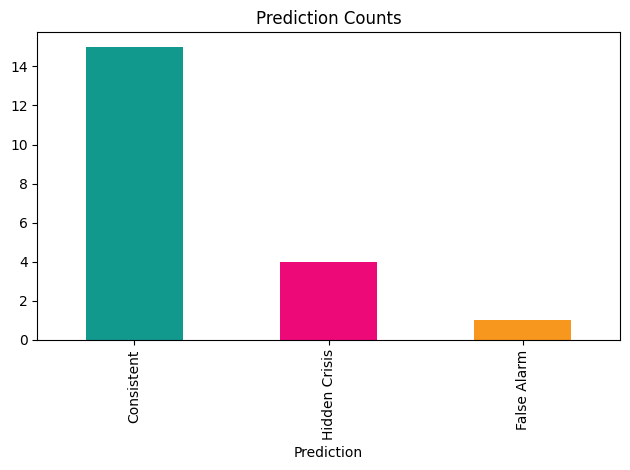

In [38]:
results["Prediction"].value_counts().plot(kind='bar', color=['#11998e','#ee0979','#f7971e'], title='Prediction Counts')
plt.tight_layout()
plt.show()

## 8. Dossier Generation

In [39]:
dossiers = []

for i in range(len(df_infer)):
    if preds[i] == 0:
        continue
    row = df_infer.iloc[i]
    delta_val = abs(inferred[i] - assigned[i])
    dossiers.append({
        "ticket_id":         f"TKT-{i}",
        "assigned_priority": row["Priority_Level"],
        "inferred_severity": round(float(inferred[i]), 3),
        "mismatch_type":     labels[i],
        "severity_delta":    round(float(delta_val), 3),
        "confidence":        round(float(proba[i]), 3),
        "feature_evidence": [
            {"signal": "text_severity",     "value": round(float(s1[i]), 3), "weight": "0.60"},
            {"signal": "metadata_severity", "value": round(float(s2[i]), 3), "weight": "0.40"},
        ],
        "constraint_analysis": (
            f"Text={s1[i]:.2f}, Metadata={s2[i]:.2f}. "
            f"Assigned={assigned[i]:.2f}, Inferred={inferred[i]:.2f}."
        ),
    })

with open("dossiers.json", "w") as f:
    json.dump(dossiers, f, indent=2)

print(f"{len(dossiers)} dossiers saved to dossiers.json")
print(json.dumps(dossiers[0], indent=2) if dossiers else "No mismatches found.")

5 dossiers saved to dossiers.json
{
  "ticket_id": "TKT-0",
  "assigned_priority": "Low",
  "inferred_severity": 0.878,
  "mismatch_type": "Hidden Crisis",
  "severity_delta": 0.728,
  "confidence": 1.0,
  "feature_evidence": [
    {
      "signal": "text_severity",
      "value": 0.9,
      "weight": "0.60"
    },
    {
      "signal": "metadata_severity",
      "value": 0.845,
      "weight": "0.40"
    }
  ],
  "constraint_analysis": "Text=0.90, Metadata=0.84. Assigned=0.15, Inferred=0.88."
}


## 9. Export Results

In [40]:
results.to_csv("predictions.csv", index=False)
print("Saved predictions.csv")
results.describe()

Saved predictions.csv


,Confidence,Inferred_Severity,Severity_Delta
count,20.000000,20.000000,20.000000
mean,0.250000,0.537000,0.397300
std,0.444262,0.227084,0.255622
min,0.000000,0.281000,0.024000
25%,0.000000,0.341250,0.197250
50%,0.000000,0.461500,0.373500
75%,0.250000,0.716000,0.661500
max,1.000000,0.878000,0.728000
